In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.metrics import roc_curve, auc , confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split


from keras.models import load_model
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import RMSprop


from dataset_preparation import awgn, LoadDataset, ChannelIndSpectrogram
from deep_learning_models import TripletNet, identity_loss

2024-05-08 19:52:56.201185: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-05-08 19:52:56.204513: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-05-08 19:52:56.244587: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-05-08 19:52:59.425441: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [7]:
# SPECIFIC MODULES INSTALLED MANUALLY
#%pip install keras
#%pip install tensorflow
#%pip install gdrive
#%pip install matplotlib


#!unzip -q /workspaces/work/dataset_training_aug.zip
training_dataset_path = "/workspaces/work/dataset_training_no_aug.h5"

In [13]:

file_path = training_dataset_path        
dev_range = np.arange(0,30, dtype = int), 
pkt_range = np.arange(0,1000, dtype = int), 
snr_range = np.arange(20,80)

LoadDatasetObj = LoadDataset()
    
# Load preamble IQ samples and labels.
data, label = LoadDatasetObj.load_iq_samples(file_path, 
                                                 dev_range, 
                                                 pkt_range)

Dataset information: Dev 1 to Dev 30, 500 packets per device.


In [19]:
#SOME PREPROCESSING
data_real_values = np.real(data).reshape(data.shape[0], 1, data.shape[1])
#data_real_values = data_real_values/np.max(data_real_values)
data_real_values.shape
data_real_values_train, data_real_values_test, label_train, label_test = train_test_split(data_real_values, label, test_size=0.2)

# HYPERPAMETER TUNNING
# learning rate of optimiser, high epochs for low lr
# padding in layer 1 and corresponding maxpooling layers in cnn_model

# NOTES
# default adam with binary_crossentropy not good, but lr=0.0001
# 0.001 sgd with binary_crossentropy good
# default focalbinary_crossentropy with default adam good
# combimed cnn+lstm with 0.001 rms prop good 

In [18]:
print(data_real_values.shape)
print(data_real_values_train.shape)
print(data_real_values_test.shape)



(1000, 1, 8192)
(800, 1, 8192)
(200, 1, 8192)


In [34]:
import tensorflow as tf
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import  Conv1D, MaxPooling1D, Flatten, Dense
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


cnn_model = Sequential()
cnn_model.add(Conv1D(filters=32, kernel_size=3, activation='relu', padding='same', input_shape=(1, 8192)))
#cnn_model.add(MaxPooling1D(pool_size=2, padding='same'))
#cnn_model.add(Dropout(0.2))
cnn_model.add(Conv1D(64, kernel_size=1, activation='relu'))
cnn_model.add(Conv1D(64, kernel_size=1, activation='relu'))
cnn_model.add(Flatten())
cnn_model.add(Dense(64, activation='relu'))
cnn_model.add(Dense(1, activation='sigmoid'))

#cnn_model.summary()

In [35]:
# Define the LSTM model
lstm_model = Sequential()
lstm_model.add(LSTM(64, activation='relu', input_shape=(1, 8192)))
lstm_model.add(Dense(128, activation='relu'))
lstm_model.add(Dropout(0.5))
lstm_model.add(Dense(1, activation='sigmoid'))



In [41]:
cnn_lstm_model = Sequential()
cnn_lstm_model.add(Conv1D(filters=32, kernel_size=3, activation='relu', padding='same', input_shape=(1, 8192)))
#cnn_lstm_model.add(MaxPooling1D(pool_size=2, padding='same'))
#cnn_lstm_model.add(Dropout(0.2))
cnn_lstm_model.add(Conv1D(64, kernel_size=1, activation='relu'))
cnn_lstm_model.add(Conv1D(64, kernel_size=1, activation='relu'))
# cnn_lstm_model.add(Flatten())
# cnn_lstm_model.add(Dense(64, activation='relu'))

cnn_lstm_model.add(LSTM(64, activation='relu'))
cnn_lstm_model.add(Dense(128, activation='relu'))
#cnn_lstm_model.add(Dropout(0.5))
cnn_lstm_model.add(Dense(1, activation='sigmoid'))

In [44]:
model_to_train = cnn_lstm_model

#loss2 = 'binary_crossentropy'
loss3 = keras.losses.BinaryFocalCrossentropy()

#optimizer = keras.optimizers.Adam(learning_rate=0.0001) #https://keras.io/api/optimizers/adam/
optimizer = keras.optimizers.RMSprop(learning_rate=0.001) # https://keras.io/api/optimizers/rmsprop/
#optimizer = keras.optimizers.SGD(learning_rate=0.001) #https://keras.io/api/optimizers/sgd/

model_to_train.compile(optimizer=optimizer, loss=loss3, metrics=['accuracy'])

train_history = model_to_train.fit(data_real_values_train, label_train, 
                                   validation_data = (data_real_values_test, label_test),
                                   epochs=100, batch_size=32)

Epoch 1/100


25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.5119 - loss: 0.1734 - val_accuracy: 0.4800 - val_loss: 0.1734
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4450 - loss: 0.1737 - val_accuracy: 0.4800 - val_loss: 0.1736
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4964 - loss: 0.1737 - val_accuracy: 0.4800 - val_loss: 0.1736
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5160 - loss: 0.1735 - val_accuracy: 0.4900 - val_loss: 0.1734
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5109 - loss: 0.1734 - val_accuracy: 0.5300 - val_loss: 0.1733
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5363 - loss: 0.1732 - val_accuracy: 0.5050 - val_loss: 0.1736
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4819 - loss: 0.1740 - val_accuracy: 0.4750 - val_loss: 0.1735
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5003 - loss: 0.1732 - val_accuracy: 0.5000 - val_loss: 0.

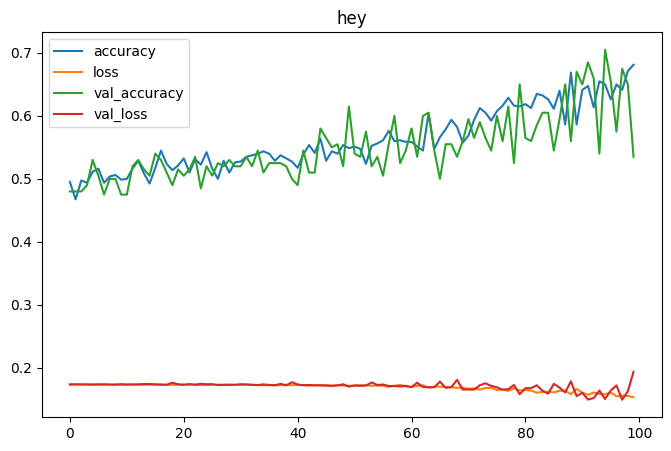

In [45]:
import pandas as pd
pd.DataFrame(train_history.history).plot(figsize=(8,5))
plt.title(f'hey')
# plt.savefig('./Plots/Base_model/7.')
plt.show()

In [30]:
print(np.unique(label))

[0]


In [29]:
a = [1,2,4,5,5]
print(np.unique(a))

[1 2 4 5]


# SPECTROGRAM 

In [14]:
def train_feature_extractor(
    file_path = 
    '/workspaces/work/dataset_training_aug.h5'
        # './dataset/Train/dataset_training_aug.h5'  
        , 
    dev_range = np.arange(0,30, dtype = int), 
    pkt_range = np.arange(0,1000, dtype = int), 
    snr_range = np.arange(20,80)
                            ):

                            
    '''
    train_feature_extractor trains an RFF extractor using triplet loss.
    
    INPUT: 
        FILE_PATH is the path of training dataset.
        
        DEV_RANGE is the label range of LoRa devices to train the RFF extractor.
        
        PKT_RANGE is the range of packets from each LoRa device to train the RFF extractor.
        
        SNR_RANGE is the SNR range used in data augmentation. 
        
    RETURN:
        FEATURE_EXTRACTOR is the RFF extractor which can extract features from
        channel-independent spectrograms.
    '''
    
    LoadDatasetObj = LoadDataset()
    
    # Load preamble IQ samples and labels.
    data, label = LoadDatasetObj.load_iq_samples(file_path, 
                                                 dev_range, 
                                                 pkt_range)
        
    # Add additive Gaussian noise to the IQ samples.
    data = awgn(data, snr_range)
    
    ChannelIndSpectrogramObj = ChannelIndSpectrogram()
    
    # Convert time-domain IQ samples to channel-independent spectrograms.
    data = ChannelIndSpectrogramObj.channel_ind_spectrogram(data)
    
    return data, label
    

In [15]:
data, label = train_feature_extractor()

# # VISUALISE A SAMPLE
# test_sample = data[3].reshape(102,62)
# plt.figure(figsize=(6, 3.2))
# plt.imshow(test_sample, cmap='viridis', interpolation='nearest')
# plt.colorbar()
# plt.title('ColorMap')
# plt.show()

Dataset information: Dev 1 to Dev 30, 1000 packets per device.


In [16]:
total_samples, height, width, _ = data.shape
data_reshaped = data.reshape(total_samples, height, width)
data_reshaped.shape

# data_real_values_train2, data_real_values_test2, label_train2, label_test2 = train_test_split(data, 
#                                                                     label, 
#                                                                     test_size=0.2, 
#                                                                     shuffle= True)

(30000, 102, 62)

In [17]:
import tensorflow as tf
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import  Conv1D, Conv2D, MaxPooling1D, MaxPooling2D, Flatten, Dense
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


cnn_model2 = Sequential()
cnn_model2.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu', padding='same', input_shape=(height, width, 1)))
#cnn_model2.add(MaxPooling1D(pool_size=2, padding='same'))
#cnn_model2.add(Dropout(0.2))
cnn_model2.add(Conv2D(64, kernel_size=1, activation='relu'))
cnn_model2.add(Conv2D(64, kernel_size=1, activation='relu'))
cnn_model2.add(Flatten())
cnn_model2.add(Dense(64, activation='relu'))
cnn_model2.add(Dense(1, activation='sigmoid'))

#cnn_model2.summary()

/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model_to_train = cnn_model2

#loss2 = 'binary_crossentropy'
loss3 = keras.losses.BinaryFocalCrossentropy()

#optimizer = keras.optimizers.Adam(learning_rate=0.0001) #https://keras.io/api/optimizers/adam/
optimizer = keras.optimizers.RMSprop(learning_rate=0.001) # https://keras.io/api/optimizers/rmsprop/
#optimizer = keras.optimizers.SGD(learning_rate=0.001) #https://keras.io/api/optimizers/sgd/

model_to_train.compile(optimizer=optimizer, loss=loss3, metrics=['accuracy'])

train_history = model_to_train.fit(data, label, 
                                   epochs=100, batch_size=32)

Epoch 1/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 204s 215ms/step - accuracy: 0.0316 - loss: -10698755145728.0000
Epoch 2/100


KeyboardInterrupt: 

In [ ]:
data[0]